# BUSA 8000 TECHNIQUES IN BUSINESS ANALYTICS

## Name: Jeebak Sabu
## Student ID: 48085847

## Section 1 : Data Cleansing

In [6]:
import pandas as pd
import numpy as np

In [7]:
shopping_data = pd.read_csv("customer_shopping_data.csv") #importing the csv file into Jupyter lab

In [8]:
shopping_data.head(5) #Used to understand the first 5 values at the top of the dataframe and check the different columns available

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon


In [9]:
shopping_data.info() #using to understand small summary of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99461 non-null  object 
 1   customer_id     99461 non-null  object 
 2   gender          99461 non-null  object 
 3   age             99461 non-null  int64  
 4   category        99461 non-null  object 
 5   quantity        99461 non-null  int64  
 6   price           99459 non-null  float64
 7   payment_method  99460 non-null  object 
 8   invoice_date    99461 non-null  object 
 9   shopping_mall   99461 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [10]:
shopping_data.describe() #Using to understand the statistical summary for the numerical columns in the dataframe

,age,quantity,price
count,99461.000000,99461.000000,99459.000000
mean,43.427796,3.003398,689.253423
std,14.990849,1.413029,941.195107
min,18.000000,1.000000,0.990000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,99.000000,5.000000,5250.000000


In [11]:
shopping_data.shape #total number of rows and columns

(99461, 10)

### Creating a new column called "total_price" which contains quantity multiplied with price(unit_price)

In [13]:
shopping_data['total_price'] = shopping_data['price']*shopping_data['quantity']

### Converting Dates to datetime format for easier analysis

In [15]:
#replacing certain date values from excel format dates to datetime to reduce the errors in invoice_dates
def convert_date(x):
    if len(str(x)) == 5:
        serial_date = int(x)
        date = pd.to_datetime(pd.Timedelta(days=serial_date - 1) + pd.to_datetime('1899-12-30'))
        return date.strftime('%d/%m/%Y')
    else:
        return str(x)

shopping_data['invoice_date'] = shopping_data['invoice_date'].apply(convert_date) 

In [16]:
shopping_data['date'] = pd.to_datetime(shopping_data['invoice_date'], format='mixed')
shopping_data['year'] = shopping_data['date'].dt.year
shopping_data['month'] = shopping_data['date'].dt.month #creating new columns date, year and month for visualizations later on.

In [17]:
shopping_data.head(3) #Displaying the newly created columns

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_price,date,year,month
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,7502.00,2022-08-05,2022,8
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53,2021-12-12,2021,12
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity,300.08,2021-11-09,2021,11


## Finding Unique values in the dataframe 

In [19]:
print("Gender unique values are :" , shopping_data['gender'].unique()) 

Gender unique values are : ['Female' 'Male' 'Mal']


In [20]:
print("Category unique values are :", shopping_data['category'].unique())

Category unique values are : ['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys' 'Clothi'
 'Technology' 'Toy' 'Boks' 'Souvenir' 'Shoe' 'Cosmetic' 'Tech' 'Food']


In [21]:
print("Payment method unique values are :", shopping_data['payment_method'].unique()) 

Payment method unique values are : ['Credit Card' 'Debit Card' 'Cash' nan '##error##' 'Cash Cash'
 'CreditCard']


In [22]:
print("Shopping mall unique values are :", shopping_data['shopping_mall'].unique())

Shopping mall unique values are : ['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center' 'Mall Istanbul']


In [23]:
corrections = {'Mal':'Male','Clothi':'Clothes','Clothing':'Clothes','Shoe':'Shoes','shoes':'Shoes','Cosmetic':'Cosmetics',
               'Tech':'Technology','Toy':'Toys','toy':'Toys','Boks':'Books','books':'Books','Souvenir':'Souvenirs','Food':'Food & Beverages',
               'Mall Istanbul':'Mall of Istanbul','CreditCard':'Credit Card', 'Cash Cash':'Cash', 'Food & Beverage':'Food & Beverages'}
shopping_data = shopping_data.replace(corrections)
shopping_data.replace(['##error##', 'nan'], np.nan, inplace=True)  #replacing incorrect values in the columns with the correct values

## Checking and dropping duplicates in the dataframe

In [25]:
shopping_data[shopping_data.duplicated(['invoice_no'])]

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_price,date,year,month
237,I218385,C290280,Female,51,Toys,1,35.84,Cash,7/19/2022,Metrocity,35.84,2022-07-19,2022,7
250,I120948,C340089,Female,54,Shoes,4,2400.68,Debit Card,8/08/2021,Mall of Istanbul,9602.72,2021-08-08,2021,8
99390,I170876,C320288,Male,40,Food & Beverages,3,15.69,Cash,8/14/2022,Metrocity,47.07,2022-08-14,2022,8


In [26]:
shopping_data.drop_duplicates(subset=['invoice_no'], inplace=True) #dropping the duplicates in the column invoice_no

## Checking for errored in the dataframe

In [28]:
pattern = r'^I\d{6}$'
invalid_rows = shopping_data[~shopping_data['invoice_no'].str.match(pattern)]
print(invalid_rows['invoice_no'].tolist()) #checking if values in invoice_no are unique as all invoice_no must be 6 digit unique numbers

[]


In [29]:
pattern = r'^C\d{6}$'
error_entries = shopping_data[~shopping_data['customer_id'].str.match(pattern)]
print(error_entries['customer_id'].tolist()) 

['C2061##']


In [30]:
shopping_data.loc[error_entries.index, 'customer_id'] = np.nan #replaced the incorrect customer_id with 'NaN'

## Checking for missing values in the dataframe

In [32]:
print("Missing Values per Column:\n ", shopping_data.isnull().sum())

Missing Values per Column:
  invoice_no        0
customer_id       1
gender            0
age               0
category          0
quantity          0
price             2
payment_method    2
invoice_date      0
shopping_mall     0
total_price       2
date              0
year              0
month             0
dtype: int64


In [33]:
shopping_rows_missing = shopping_data[shopping_data.isna().any(axis=1)] 
shopping_rows_missing #checking for values having at least 1 'NaN' values

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_price,date,year,month
64,I218590,C224743,Female,29,Cosmetics,4,NaN,Debit Card,5/09/2022,Metropol AVM,NaN,2022-05-09,2022,5
298,I215906,C296862,Male,21,Clothes,4,1200.32,NaN,8/13/2021,Mall of Istanbul,4801.28,2021-08-13,2021,8
419,I177957,C653357,Male,65,Clothes,4,NaN,Cash,7/04/2021,Cevahir AVM,NaN,2021-07-04,2021,7
53606,I565111,C223892,Female,99,Books,1,0.99,NaN,11/01/2023,Mall of Istanbul,0.99,2023-11-01,2023,11
99418,I166977,NaN,Female,34,Cosmetics,5,203.30,Credit Card,04/02/2022,Kanyon,1016.50,2022-04-02,2022,4


In [34]:
shopping_data.dropna(subset = ['customer_id'], inplace = True) #dropping because invalid customer_id

In [35]:
shopping_data['price'] = shopping_data['price'].fillna(shopping_data['price'].median()) #replacing 'NaN' values in price column with median

In [36]:
#replacing 'NaN' values in payment_method with mode from the column
shopping_data['payment_method'] = shopping_data['payment_method'].fillna(shopping_data['payment_method'].mode()[0])

In [37]:
shopping_data.dropna(subset = ['total_price'], inplace = True) #dropped 'NaN' values in price as in does not affect the result in a major way

In [38]:
shopping_data[shopping_data.isna().any(axis=1)] #confirming if there are any duplicates left

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_price,date,year,month


## Histograms

In [40]:
import matplotlib.pyplot as plt


import seaborn as sns
import numpy as np
from scipy import stats

Text(0, 0.5, 'Frequency')

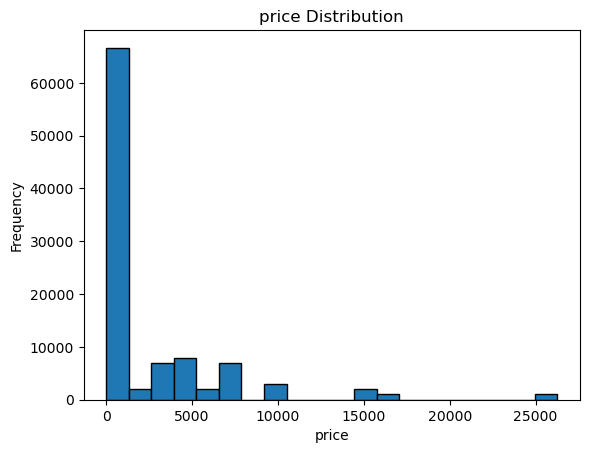

In [41]:
#checking for skewness in the price column
plt.hist(shopping_data['total_price'], bins=20, edgecolor='black')
plt.title('price Distribution')
plt.xlabel('price')
plt.ylabel('Frequency')

In [42]:
skewness_before = shopping_data['total_price'].skew()
skewness_before

2.87108038968413

## Outliers

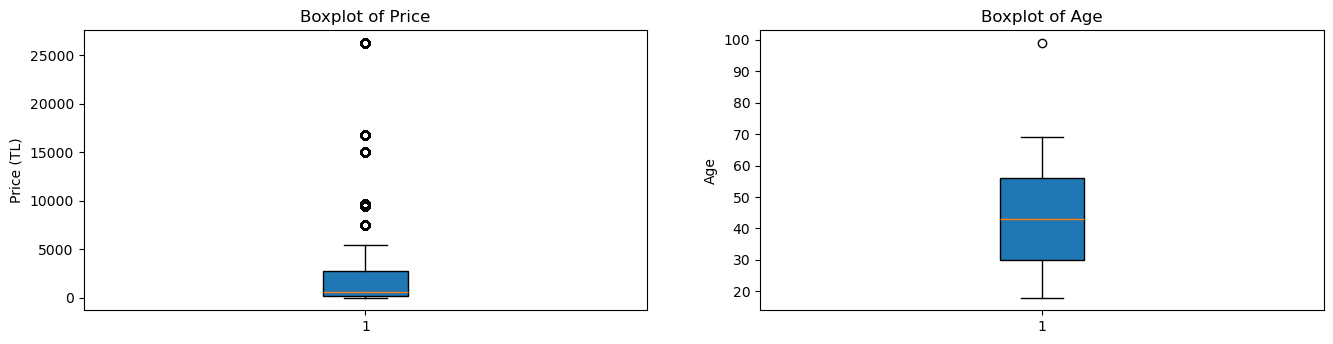

In [44]:
# Creating boxplots to identify outliers
plt.figure(figsize=(16, 8))

# Price boxplot
plt.subplot(2, 2, 1)
plt.boxplot(shopping_data['total_price'], patch_artist=True)
plt.title('Boxplot of Price')
plt.ylabel('Price (TL)')

# Age boxplot
plt.subplot(2, 2, 2)
plt.boxplot(shopping_data['age'], patch_artist=True)
plt.title('Boxplot of Age')
plt.ylabel('Age')

plt.show()

Although I noticed a few outliers in the boxplot of Price and Age, I am checking if it is affecting any category or the results of my Analysis

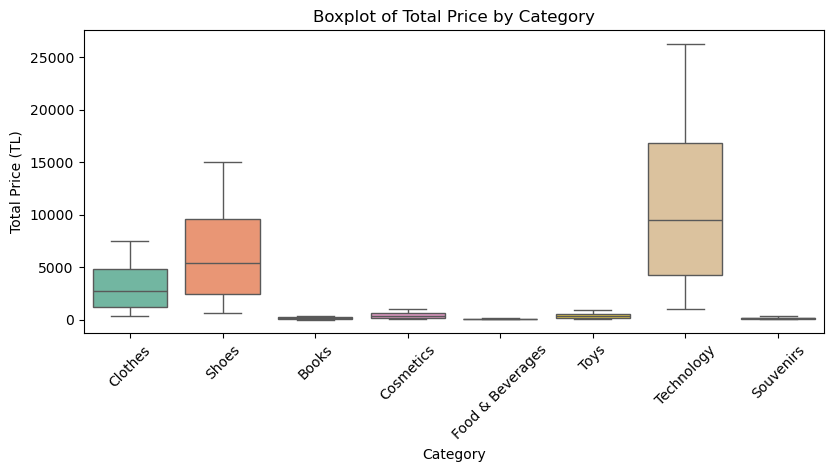

In [46]:
plt.figure(figsize=(16, 8))

# Boxplot of Total Price grouped by Category
plt.subplot(2, 2, 1)
sns.boxplot(x='category', y='total_price', hue='category',data=shopping_data, palette="Set2")
plt.title('Boxplot of Total Price by Category')
plt.xlabel('Category')
plt.ylabel('Total Price (TL)')
plt.xticks(rotation=45)  # Rotate category labels for better readability

# Display the plots
plt.tight_layout() 
plt.show()

Since it is not affecting my analysis in any way, I chose to ignore the outliers and move ahead.

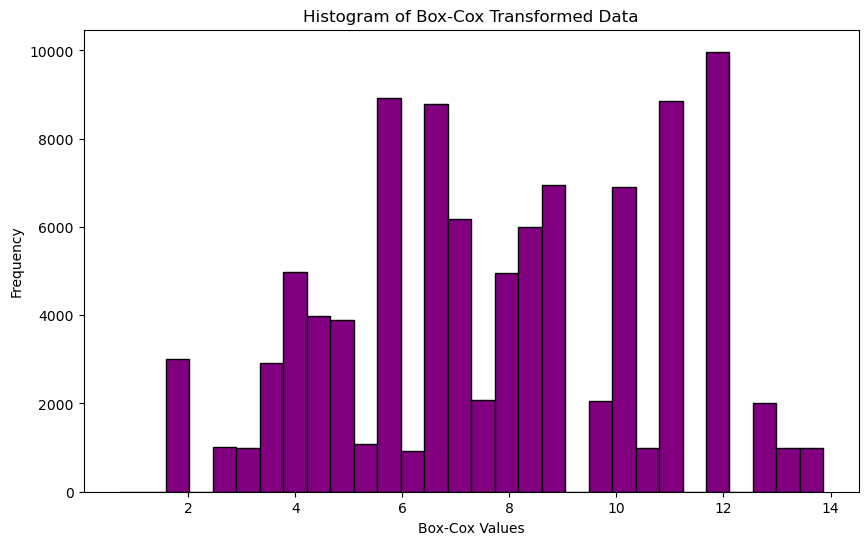

In [48]:
# Applying Box-Cox transformation to fix skewness
shopping_data['total_price'], _ = stats.boxcox(shopping_data['total_price'] + 1)  # Adding 1 to handle zero values

# Displaying histogram after Box-Cox transformation
plt.figure(figsize=(10, 6))
plt.hist(shopping_data['total_price'], bins=30, color='purple', edgecolor='black')
plt.title('Histogram of Box-Cox Transformed Data')
plt.xlabel('Box-Cox Values')
plt.ylabel('Frequency')
plt.show()

In [49]:
# Calculating skewness after log transformation
skewness_after_log = shopping_data['total_price'].skew()
skewness_after_log

-0.03480430678095396

## Section 2: Analysis 

Based on your analysis, which customer segments/categories should the shopping mall target for marketing campaigns?

In [52]:
#calculating spending scores for each customer
customer_spending = shopping_data.groupby('customer_id')['total_price'].sum().reset_index()
customer_spending.columns = ['customer_id', 'total_spending']
customer_spending['spending_score'] = 100 * (customer_spending['total_spending'] - customer_spending['total_spending'].min()) / (customer_spending['total_spending'].max() - customer_spending['total_spending'].min())
shopping_data = shopping_data.merge(customer_spending[['customer_id', 'spending_score']], on='customer_id', how='left')

shopping_data. head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_price,date,year,month,spending_score
0,I138884,C241288,Female,28,Clothes,5,1500.40,Credit Card,8/05/2022,Kanyon,11.687791,2022-08-05,2022,8,81.741444
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,11.141926,2021-12-12,2021,12,77.168728
2,I127801,C266599,Male,20,Clothes,1,300.08,Cash,11/09/2021,Metrocity,6.765500,2021-11-09,2021,11,40.507387
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM,12.874428,2021-05-16,2021,5,91.681908
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon,6.471197,2021-10-24,2021,10,38.042009


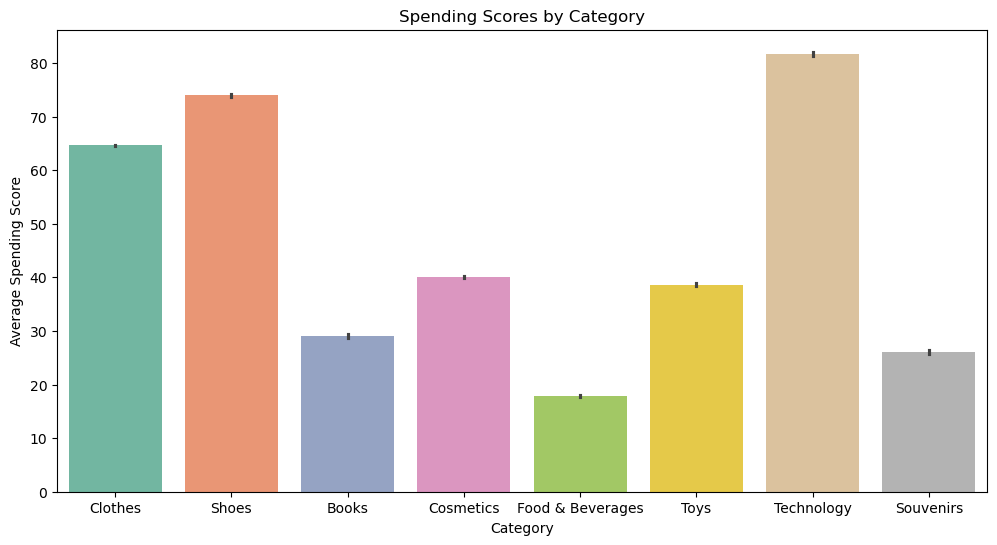

In [53]:
#Visualising spending score by category
plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='spending_score', hue='category', data=shopping_data, palette="Set2")

plt.title('Spending Scores by Category')
plt.xlabel('Category')
plt.ylabel('Average Spending Score')
plt.show()

Create a box plot to compare the distribution of spending scores between male and female customers. What can you infer from the box plot about the spending behaviour of different genders?

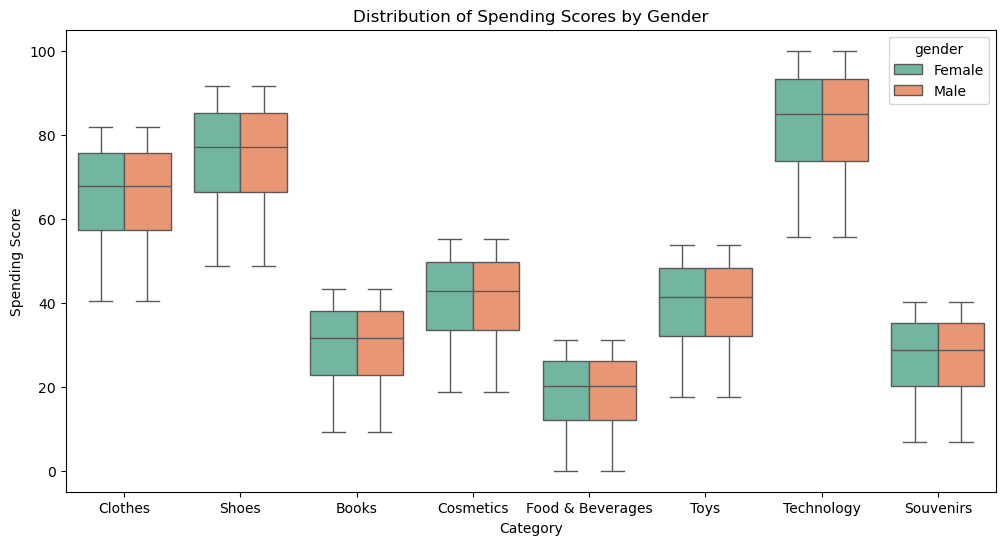

In [55]:
#visualising spending score by gender
plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='spending_score', hue='gender', data=shopping_data,  palette="Set2")

plt.title('Distribution of Spending Scores by Gender')
plt.xlabel('Category')
plt.ylabel('Spending Score')
plt.show()

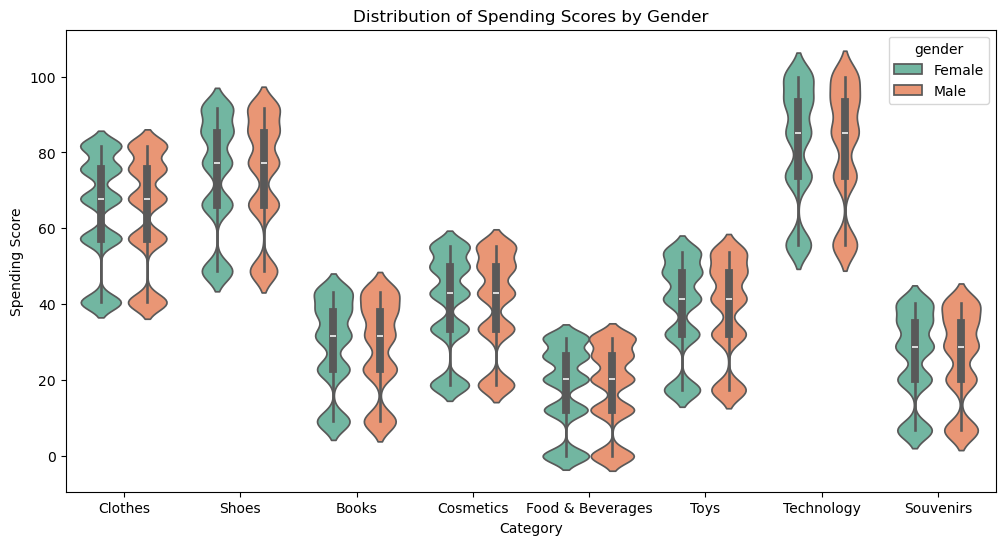

In [56]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='category', y='spending_score', hue='gender', data=shopping_data,  palette="Set2")

plt.title('Distribution of Spending Scores by Gender')
plt.xlabel('Category')
plt.ylabel('Spending Score')
plt.show()

In [57]:
#checking if the above visualizzation is correct
median_scores = shopping_data.groupby(['gender', 'category'])['spending_score'].median().reset_index()
print(median_scores)

    gender          category  spending_score
0   Female             Books       31.558086
1   Female           Clothes       67.801690
2   Female         Cosmetics       42.828106
3   Female  Food & Beverages       20.206272
4   Female             Shoes       77.168728
5   Female         Souvenirs       28.750943
6   Female        Technology       85.007572
7   Female              Toys       41.349062
8     Male             Books       31.558086
9     Male           Clothes       67.801690
10    Male         Cosmetics       42.828106
11    Male  Food & Beverages       20.206272
12    Male             Shoes       77.168728
13    Male         Souvenirs       28.750943
14    Male        Technology       85.007572
15    Male              Toys       41.349062


In [58]:
median_scores.groupby('gender')['spending_score'].sum()

gender
Female    394.67046
Male      394.67046
Name: spending_score, dtype: float64

Create a scatter plot to visualise the relationship between age and spending. What insights can you derive from this visualization? Is there a correlation between age and spending?

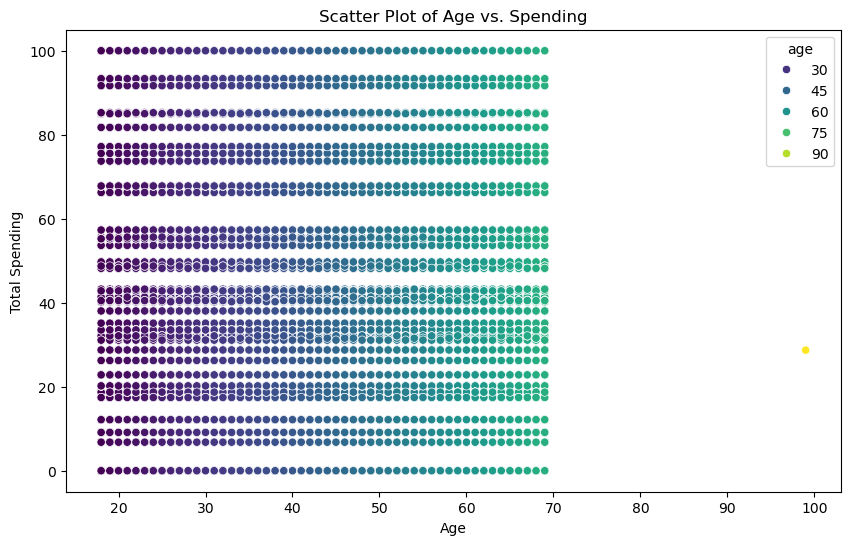

In [60]:
#visualizing the relationship between Age and Spending scores
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='spending_score', hue = 'age',palette='viridis',  data=shopping_data)
plt.title('Scatter Plot of Age vs. Spending')
plt.xlabel('Age')
plt.ylabel('Total Spending')

plt.show()

In [61]:
#finding correlation between age and spending score 
correlation = shopping_data['age'].corr(shopping_data['spending_score'])
print(f'Correlation between Age and Spending: {correlation:.2f}')

Correlation between Age and Spending: 0.00


Segment the customers into different age groups (e.g., 18-25, 26-35, 36-45, 46-55, 56+). How does the spending score vary across these age groups? Provide a visualisation to support your analysis.

C:\Users\Jeebak\AppData\Local\Temp\ipykernel_5044\1162088169.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_spending_score = shopping_data.groupby(['Age Group', 'category'])['spending_score'].mean().unstack()


<Figure size 1200x800 with 0 Axes>

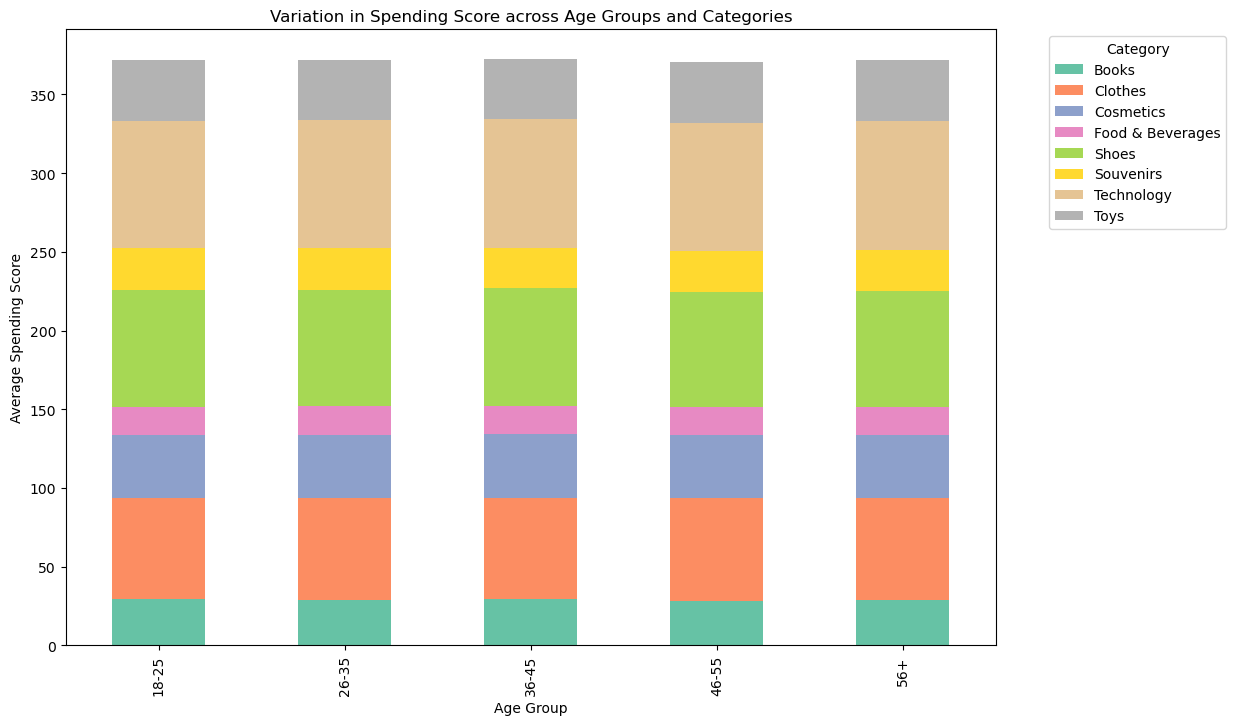

In [63]:
#Creating a new column Age group using age
shopping_data['Age Group'] = pd.cut(shopping_data['age'], bins=[18, 25, 35, 45, 55, float('inf')], labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# Calculating the average spending score grouped by Age Group and Category
avg_spending_score = shopping_data.groupby(['Age Group', 'category'])['spending_score'].mean().unstack()

#Variation in spending score across age groups and categories
plt.figure(figsize=(12, 8))
avg_spending_score.plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 8))
plt.title('Variation in Spending Score across Age Groups and Categories')
plt.xlabel('Age Group')
plt.ylabel('Average Spending Score')


plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')  # Position the legend outside the plot
plt.show()


## Section 3: Recommendations

### Sales by Payment Method:

payment_method
Cash           347884.185172
Credit Card    273252.158851
Debit Card     157235.079657
Name: total_price, dtype: float64


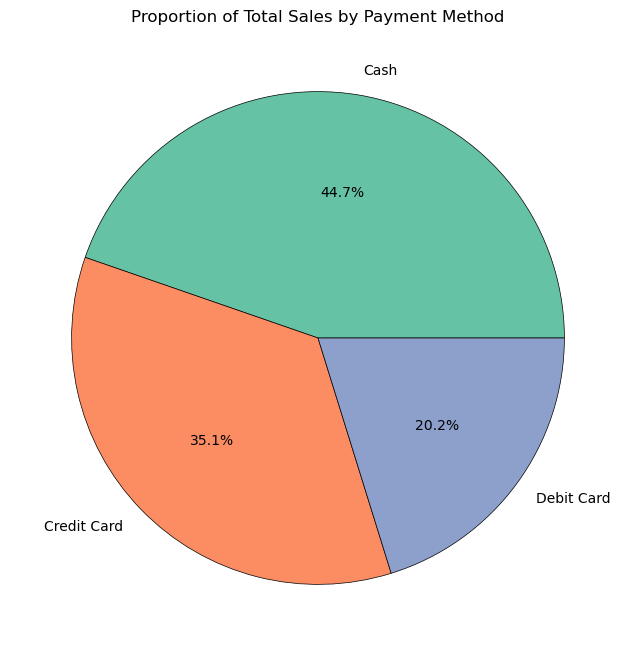

In [66]:
#calculating Total sales by payment method
payment_sales = shopping_data.groupby('payment_method')['total_price'].sum()
print(payment_sales)
plt.figure(figsize=(8, 8))
plt.pie(payment_sales, labels=payment_sales.index, autopct='%1.1f%%', colors=sns.color_palette("Set2"), wedgeprops={'edgecolor': 'black', 'linewidth': .5})
plt.title('Proportion of Total Sales by Payment Method')
plt.show()

### Sales Trend Over Time:

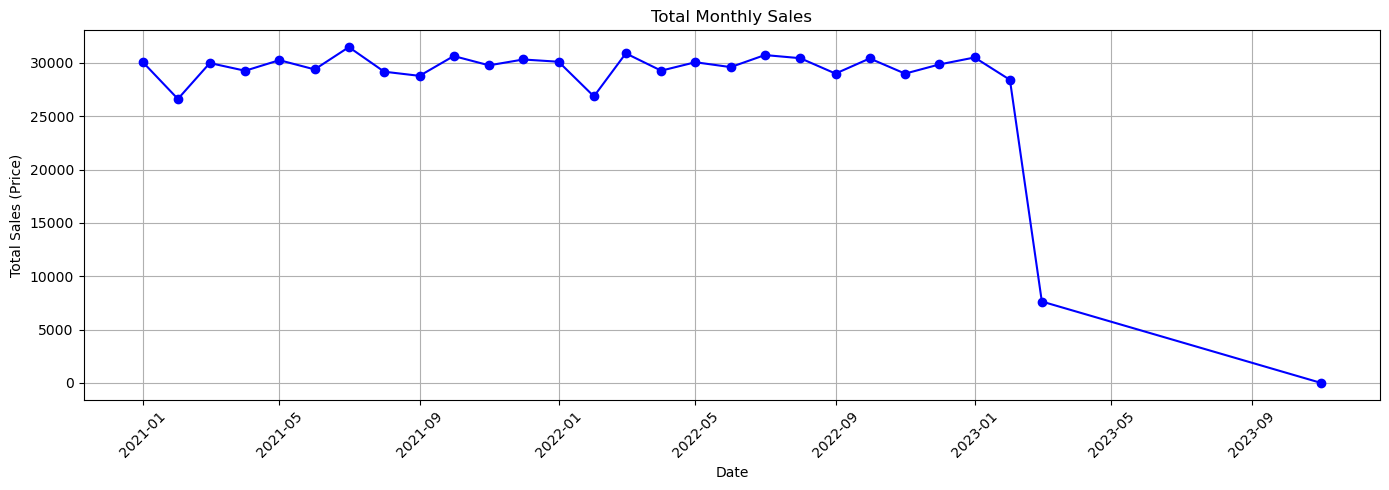

In [68]:
#The full sales trend overtime
# Combining year and month into a 'Date' column
shopping_data['Date'] = pd.to_datetime(shopping_data[['year', 'month']].assign(day=1))

# Aggregate total sales by month
monthly_sales = shopping_data.groupby('Date')['total_price'].sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='b')
plt.title('Total Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales (Price)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
